In [108]:
import csv
import pandas as pd

# カテゴリ別のカラムインデックス（0-based）
CATEGORY_INDEXES = {
    "sus": list(range(1, 11)),
    "tam": list(range(11, 14)),
    "trust": list(range(14, 18)),
    "trust2": list(range(18, 29)),
    "nasa": list(range(29, 38)),
    "participant_id": 38,
    "condition": 39
}


# 結果格納用
results = {
    "sus": [],
    "tam": [],
    "trust": [],
    "trust2": [],
    "nasa": [],
    "participant_ids": [],
    "conditions": []
}

# ファイル読み込み（ファイルパスを指定）
with open("SurvayResult.csv", newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    header = next(reader)  # ヘッダー読み飛ばし

    for row in reader:
        for key in ["sus", "tam", "trust", "trust2", "nasa"]:
            indexes = CATEGORY_INDEXES[key]
            results[key].append([int(row[i]) for i in indexes])

        results["participant_ids"].append(row[CATEGORY_INDEXES["participant_id"]])
        results["conditions"].append(int(row[CATEGORY_INDEXES["condition"]]))




In [109]:
df_result["participant_ids"] = df_result["participant_ids"].astype(str)
df_valid = df_result[~df_result["participant_ids"].isin(["0", "TEST"])].copy()


df_valid

,sus,tam,trust,trust2,nasa,participant_ids,conditions
8,"[5, 1, 5, 1, 5, 1, 5, 1, 5, 1]","[7, 7, 7]","[5, 5, 5, 5]","[5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 5]","[0, 0, 0, 10, 0, 0, 0, 2, 0]",P1,1
9,"[5, 1, 5, 1, 5, 1, 5, 1, 5, 1]","[7, 7, 7]","[5, 5, 5, 5]","[5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 5]","[0, 0, 0, 10, 0, 0, 0, 1, 0]",P1,4
10,"[4, 2, 4, 2, 3, 1, 4, 3, 2, 1]","[6, 4, 3]","[5, 4, 5, 3]","[4, 4, 3, 5, 3, 3, 3, 5, 1, 5, 2]","[7, 0, 0, 5, 7, 0, 2, 1, 0]",P1,2
11,"[5, 1, 5, 1, 5, 1, 5, 1, 5, 1]","[7, 7, 7]","[5, 5, 5, 5]","[5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 5]","[0, 0, 0, 10, 0, 0, 0, 1, 0]",P1,3
12,"[4, 2, 4, 4, 5, 1, 5, 1, 4, 4]","[6, 5, 5]","[5, 4, 4, 4]","[4, 4, 3, 5, 4, 5, 4, 5, 1, 1, 3]","[6, 7, 1, 8, 2, 2, 8, 9, 7]",P2,3
13,"[4, 1, 4, 4, 5, 1, 4, 2, 2, 4]","[5, 6, 4]","[5, 4, 4, 4]","[4, 4, 5, 4, 4, 5, 4, 5, 1, 2, 4]","[7, 7, 1, 6, 8, 2, 7, 8, 5]",P2,1
14,"[3, 3, 4, 4, 5, 1, 4, 1, 4, 4]","[5, 5, 6]","[5, 5, 5, 4]","[4, 4, 5, 5, 4, 5, 4, 5, 1, 1, 4]","[6, 7, 1, 7, 8, 1, 7, 7, 5]",P2,2
15,"[4, 2, 4, 4, 5, 1, 4, 2, 3, 4]","[6, 6, 6]","[5, 4, 5, 4]","[5, 4, 5, 5, 4, 5, 4, 5, 1, 2, 4]","[7, 8, 1, 4, 8, 1, 7, 8, 6]",P2,4


# 1.SUS解析をしていく

###　SUSスコアを計算する

In [45]:
# SUSスコアの補正計算関数
def calc_sus_score(raw_scores):
    adjusted = []
    for i, score in enumerate(raw_scores):
        if (i + 1) % 2 == 1:  # 奇数: -1
            adjusted.append(score - 1)
        else:  # 偶数: 5 - score
            adjusted.append(5 - score)
    return sum(adjusted) * 2.5

# 行ごとの処理を関数として定義
def extract_sus_info(row):
    condition = row["conditions"]
    sus_score = calc_sus_score(row["sus"])
    return pd.Series({
        "condition": condition,
        "sus_score": sus_score
    })

# 適用
df_sus = df_valid.apply(extract_sus_info, axis=1)



# 条件ごとの平均SUSスコア
mean_scores = df_sus.groupby("condition")["sus_score"].mean()

# 条件ごとの標準誤差（信頼区間付きグラフに使う）
sem_scores = df_sus.groupby("condition")["sus_score"].sem()


sem_scores

condition
1.0    16.25
2.0     1.25
3.0    12.50
4.0    16.25
Name: sus_score, dtype: float64

### 有意差検定 (Friedman検)

In [46]:
df_sus_wide = df_sus.copy()
df_sus_wide["participant_ids"] = df_valid["participant_ids"].values  # 忘れずにID復元

# ピボット: 行=参加者, 列=条件, 値=susスコア
df_pivot = df_sus_wide.pivot(index="participant_ids", columns="condition", values="sus_score")


from scipy.stats import friedmanchisquare

# 各条件のスコア列を取り出して渡す
stat, p = friedmanchisquare(
    df_pivot[1],
    df_pivot[2],
    df_pivot[3],
    df_pivot[4]
)

print(f"Friedman検定: p = {p:.4g}, 統計量 = {stat:.4f}")


Friedman検定: p = 0.2615, 統計量 = 4.0000


### 事後検定（Dunn's Test)

In [47]:
import scikit_posthocs as sp

import pandas as pd

# sus_condition_df に 'condition'（int型）と 'sus_score'（float型）があると仮定
posthoc_result = sp.posthoc_dunn(
    df_sus,
    val_col='sus_score',
    group_col='condition',
    p_adjust='bonferroni'
)

# 表示（条件ごとのペアごとのp値行列）
posthoc_result

,1.0,2.0,3.0,4.0
1.0,1.0,1.0,1.0,1.0
2.0,1.0,1.0,1.0,1.0
3.0,1.0,1.0,1.0,1.0
4.0,1.0,1.0,1.0,1.0


### スコアを可視化してみる

In [38]:
import matplotlib.pyplot as plt
import matplotlib
import warnings
import seaborn
# フォント設定（日本語表示対応）
matplotlib.rcParams['font.family'] = 'Meiryo'

# ユーザー警告を非表示にする
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")



plt.figure(figsize=(8, 6))
sns.boxplot(data=sus_condition_df, x='condition', y='sus_score', palette='pastel')
sns.swarmplot(data=sus_condition_df, x='condition', y='sus_score', color='black', alpha=0.7)

plt.title('SUSスコアの条件別比較')
plt.xlabel('条件')
plt.ylabel('SUSスコア')
plt.ylim(0, 100)
plt.grid(True)
plt.show()


# グループごとの平均と標準誤差
mean_scores = sus_condition_df.groupby('condition')['sus_score'].mean()
sem_scores = sus_condition_df.groupby('condition')['sus_score'].sem()

plt.figure(figsize=(8, 6))
plt.bar(mean_scores.index.astype(str), mean_scores.values, yerr=sem_scores.values, capsize=5, color='skyblue')
plt.title('条件別SUSスコア（平均 ± SE）')
plt.xlabel('条件')
plt.ylabel('SUSスコア')
plt.ylim(0, 100)
plt.grid(True, axis='y')
plt.show()




NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [48]:
def plot_score_by_condition(results_df, score_key, title_label):
    # 各被験者のスコア平均を計算（例: tam列 → [5, 6, 7] → 6.0）
    score_means = results_df[score_key].apply(lambda x: np.mean(x))
    conditions = results_df["conditions"]

    # DataFrameに整形
    df_score = pd.DataFrame({
        "score": score_means,
        "condition": conditions
    })

    # Boxplot + Swarmplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_score, x='condition', y='score', palette='pastel')
    sns.swarmplot(data=df_score, x='condition', y='score', color='black', alpha=0.7)
    plt.title(f'{title_label} の条件別比較')
    plt.xlabel('条件')
    plt.ylabel(title_label)
    plt.grid(True)
    plt.show()

    # 平均と標準誤差
    mean_scores = df_score.groupby('condition')['score'].mean()
    sem_scores = df_score.groupby('condition')['score'].sem()

    plt.figure(figsize=(8, 6))
    plt.bar(mean_scores.index.astype(str), mean_scores.values, yerr=sem_scores.values, capsize=5, color='skyblue')
    plt.title(f'{title_label}（平均 ± SE）')
    plt.xlabel('条件')
    plt.ylabel(title_label)
    plt.ylim(0, max(mean_scores.max() + sem_scores.max(), 7))  # スケール調整
    plt.grid(True, axis='y')
    plt.show()


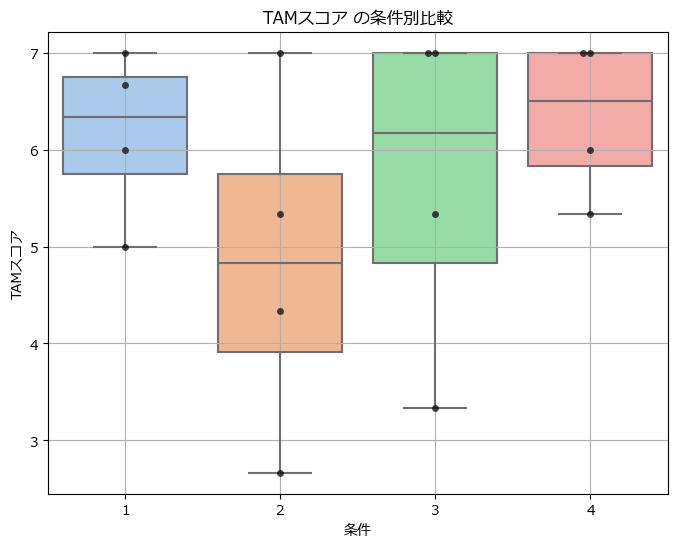

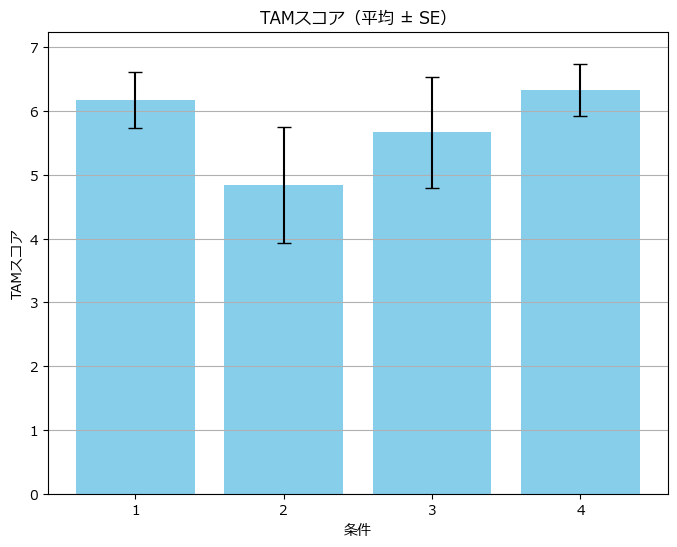

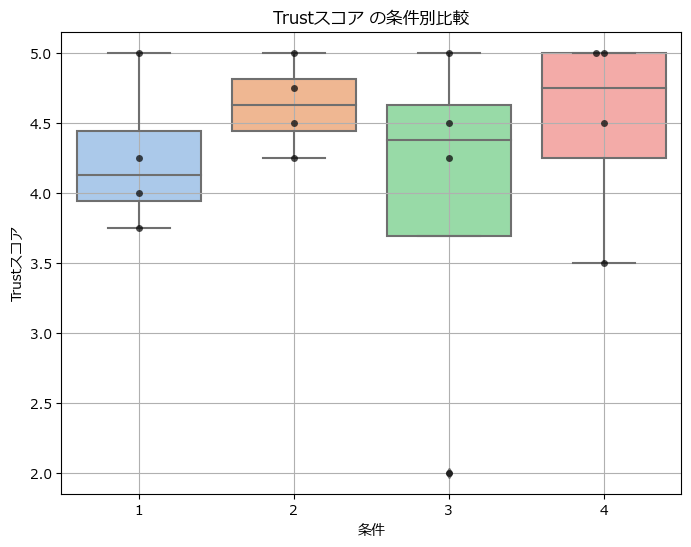

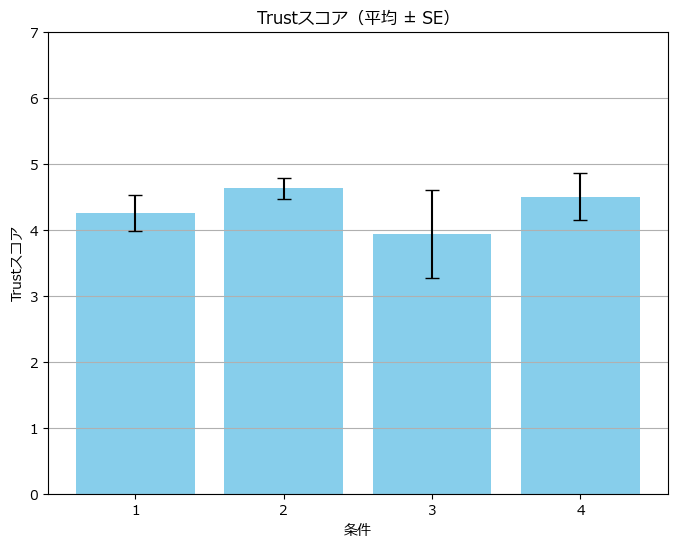

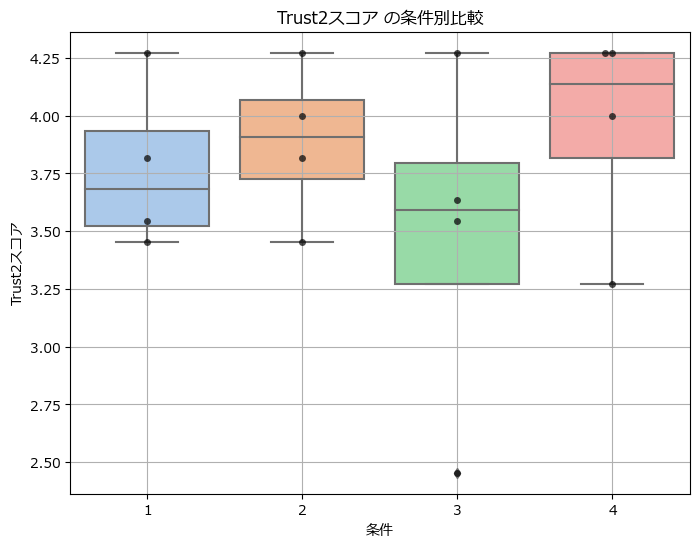

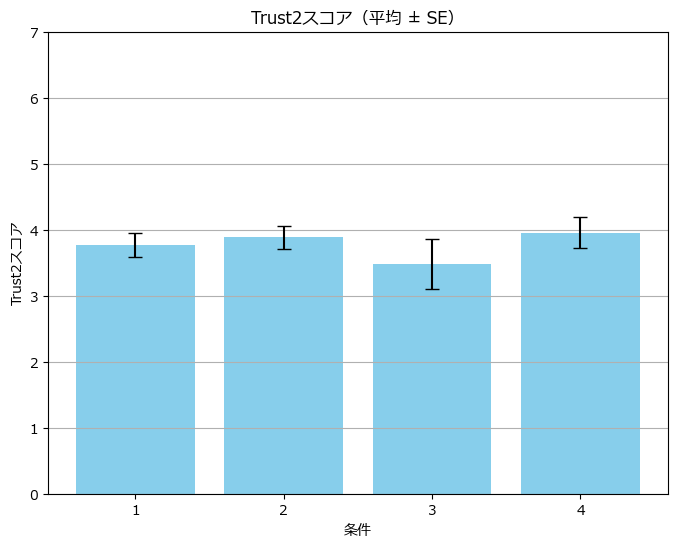

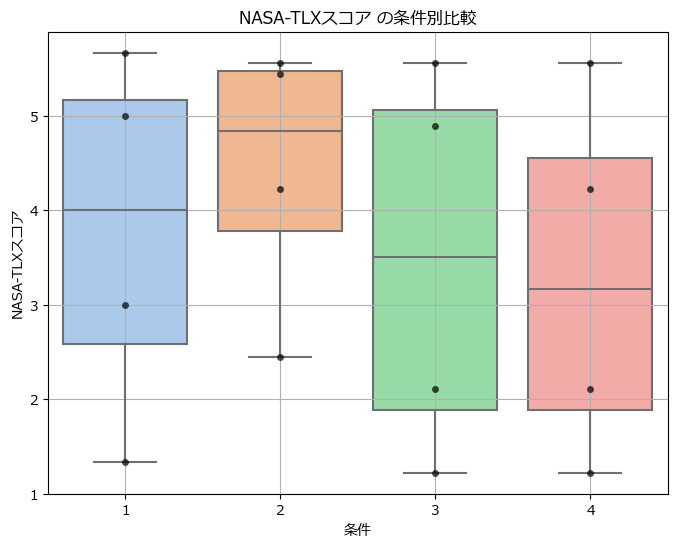

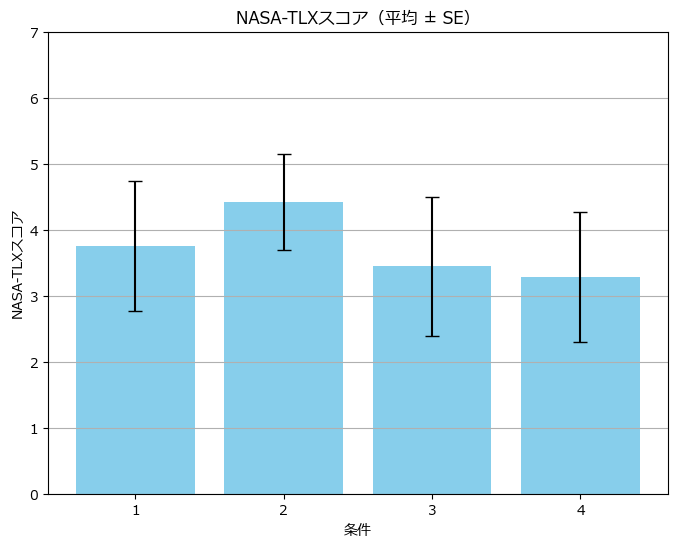

In [51]:
results_df = pd.DataFrame(results)
import pandas as pd

# もしまだ変換していないなら
results_df = pd.DataFrame(results)

# スコアごとに描画
for key, label in [("tam", "TAMスコア"), ("trust", "Trustスコア"), ("trust2", "Trust2スコア"), ("nasa", "NASA-TLXスコア")]:
    plot_score_by_condition(results_df, key, label)


### DF化する

In [104]:
import pandas as pd
import numpy as np
# SUSスコアの補正計算関数
def calc_sus_score(raw_scores):
    adjusted = []
    for i, score in enumerate(raw_scores):
        if (i + 1) % 2 == 1:  # 奇数: -1
            adjusted.append(score - 1)
        else:  # 偶数: 5 - score
            adjusted.append(5 - score)
    return sum(adjusted) * 2.5

# 行ごとの処理を関数として定義
def extract_sus_info(row):
    condition = row["conditions"]
    sus_score = calc_sus_score(row["sus"])
    return pd.Series({
        "condition": condition,
        "sus_score": sus_score
    })


df_sus = df_valid.apply(extract_sus_info, axis=1)




# trust2: 26番と27番を反転（index 8, 9）
df_valid["trust2"] = df_valid["trust2"].apply(
    lambda scores: [6 - score if i in [8, 9] else score for i, score in enumerate(scores)]
)

# nasa: 32番（index 3）を反転
df_valid["nasa"] = df_valid["nasa"].apply(
    lambda scores: [6 - score if i == 3 else score for i, score in enumerate(scores)]
)



df_tam = pd.DataFrame({
    'participant_id': df_valid["participant_ids"],
    'condition': df_valid["conditions"],
    'tam_score': [np.mean(vals) for vals in df_valid["tam"]],
})

df_trust = pd.DataFrame({
    'participant_id': df_valid["participant_ids"],
    'condition': df_valid["conditions"],
    'trust_score': [np.mean(vals) for vals in df_valid["trust"]],
})

df_trust2 = pd.DataFrame({
    'participant_id': df_valid["participant_ids"],
    'condition': df_valid["conditions"],
    'trust2_score': [np.mean(vals) for vals in df_valid["trust2"]],
})


df_nasa = pd.DataFrame({
    'participant_id': df_valid["participant_ids"],
    'condition': df_valid["conditions"],
    'nasa_total': [np.mean(vals) for vals in df_valid["nasa"]],
})




### 検定（例：TAMスコア）

In [96]:
from scipy.stats import kruskal
import scikit_posthocs as sp

# === TAM ===
groups_tam = [df_tam[df_tam['condition'] == cond]['tam_score'] for cond in df_tam['condition'].unique()]
tam_stat, tam_p = kruskal(*groups_tam)
print(f"[TAM] Kruskal-Wallis p = {tam_p:.4f}")

# Dunn's test（必要な場合）
posthoc_tam = None
if tam_p < 0.05:
    posthoc_tam = sp.posthoc_dunn(df_tam, val_col='tam_score', group_col='condition', p_adjust='bonferroni')


# === Trust ===
groups_trust = [df_trust[df_trust['condition'] == cond]['trust_score'] for cond in df_trust['condition'].unique()]
trust_stat, trust_p = kruskal(*groups_trust)
print(f"[Trust] Kruskal-Wallis p = {trust_p:.4f}")

posthoc_trust = None
if trust_p < 0.05:
    posthoc_trust = sp.posthoc_dunn(df_trust, val_col='trust_score', group_col='condition', p_adjust='bonferroni')


# === Trust2 ===
groups_trust2 = [df_trust2[df_trust2['condition'] == cond]['trust2_score'] for cond in df_trust2['condition'].unique()]
trust2_stat, trust2_p = kruskal(*groups_trust2)
print(f"[Trust2] Kruskal-Wallis p = {trust2_p:.4f}")

posthoc_trust2 = None
if trust2_p < 0.05:
    posthoc_trust2 = sp.posthoc_dunn(df_trust2, val_col='trust2_score', group_col='condition', p_adjust='bonferroni')


[TAM] Kruskal-Wallis p = 0.3916
[Trust] Kruskal-Wallis p = 0.3916
[Trust2] Kruskal-Wallis p = 0.3916


In [101]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import scikit_posthocs as sp

# 条件名のマッピング
condition_labels = {
    1: "Prompting (WoZ)",
    2: "Label (WoZ)",
    3: "Pointing (WoZ)",
    4: "Prompting (System)"
}

# DataFrameリストと対応する列名・ラベル
score_dfs = [
    ("SUS", df_sus, "sus_score"),
    ("TAM", df_tam, "tam_score"),
    ("Trust", df_trust, "trust_score"),
    ("Trust2", df_trust2, "trust2_score")
]

# すべてのDataFrameで条件ラベルを適用
for _, df, _ in score_dfs:
    df["condition"] = df["condition"].replace(condition_labels)

# 有意差検定と事後検定
for label, df, score_col in score_dfs:
    print(f"\n🔎 {label} の有意差検定")

    # Kruskal-Wallis検定
    groups = [df[df["condition"] == cond][score_col] for cond in condition_labels.values()]
    stat, p = kruskal(*groups)
    print(f"Kruskal-Wallis 統計量 = {stat:.4f}, p値 = {p:.4f}")

    # 有意差があった場合のみ事後検定
    if p < 0.05:
        print("➡️ 有意差あり → Dunn’s test（Bonferroni補正）")
        posthoc = sp.posthoc_dunn(df, val_col=score_col, group_col="condition", p_adjust='bonferroni')
        print(posthoc)
    else:
        print("❎ 有意差なし → Dunn’s test はスキップ")



🔎 SUS の有意差検定
Kruskal-Wallis 統計量 = 1.6579, p値 = 0.6463
❎ 有意差なし → Dunn’s test はスキップ

🔎 TAM の有意差検定
Kruskal-Wallis 統計量 = 2.7911, p値 = 0.4250
❎ 有意差なし → Dunn’s test はスキップ

🔎 Trust の有意差検定
Kruskal-Wallis 統計量 = 0.7368, p値 = 0.8645
❎ 有意差なし → Dunn’s test はスキップ

🔎 Trust2 の有意差検定
Kruskal-Wallis 統計量 = 1.7278, p値 = 0.6308
❎ 有意差なし → Dunn’s test はスキップ


C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\

SUS: H=3.000, p=0.392
TAM: H=3.000, p=0.392
Trust: H=3.000, p=0.392
Trust2: H=3.000, p=0.392


C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\117270767.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Te

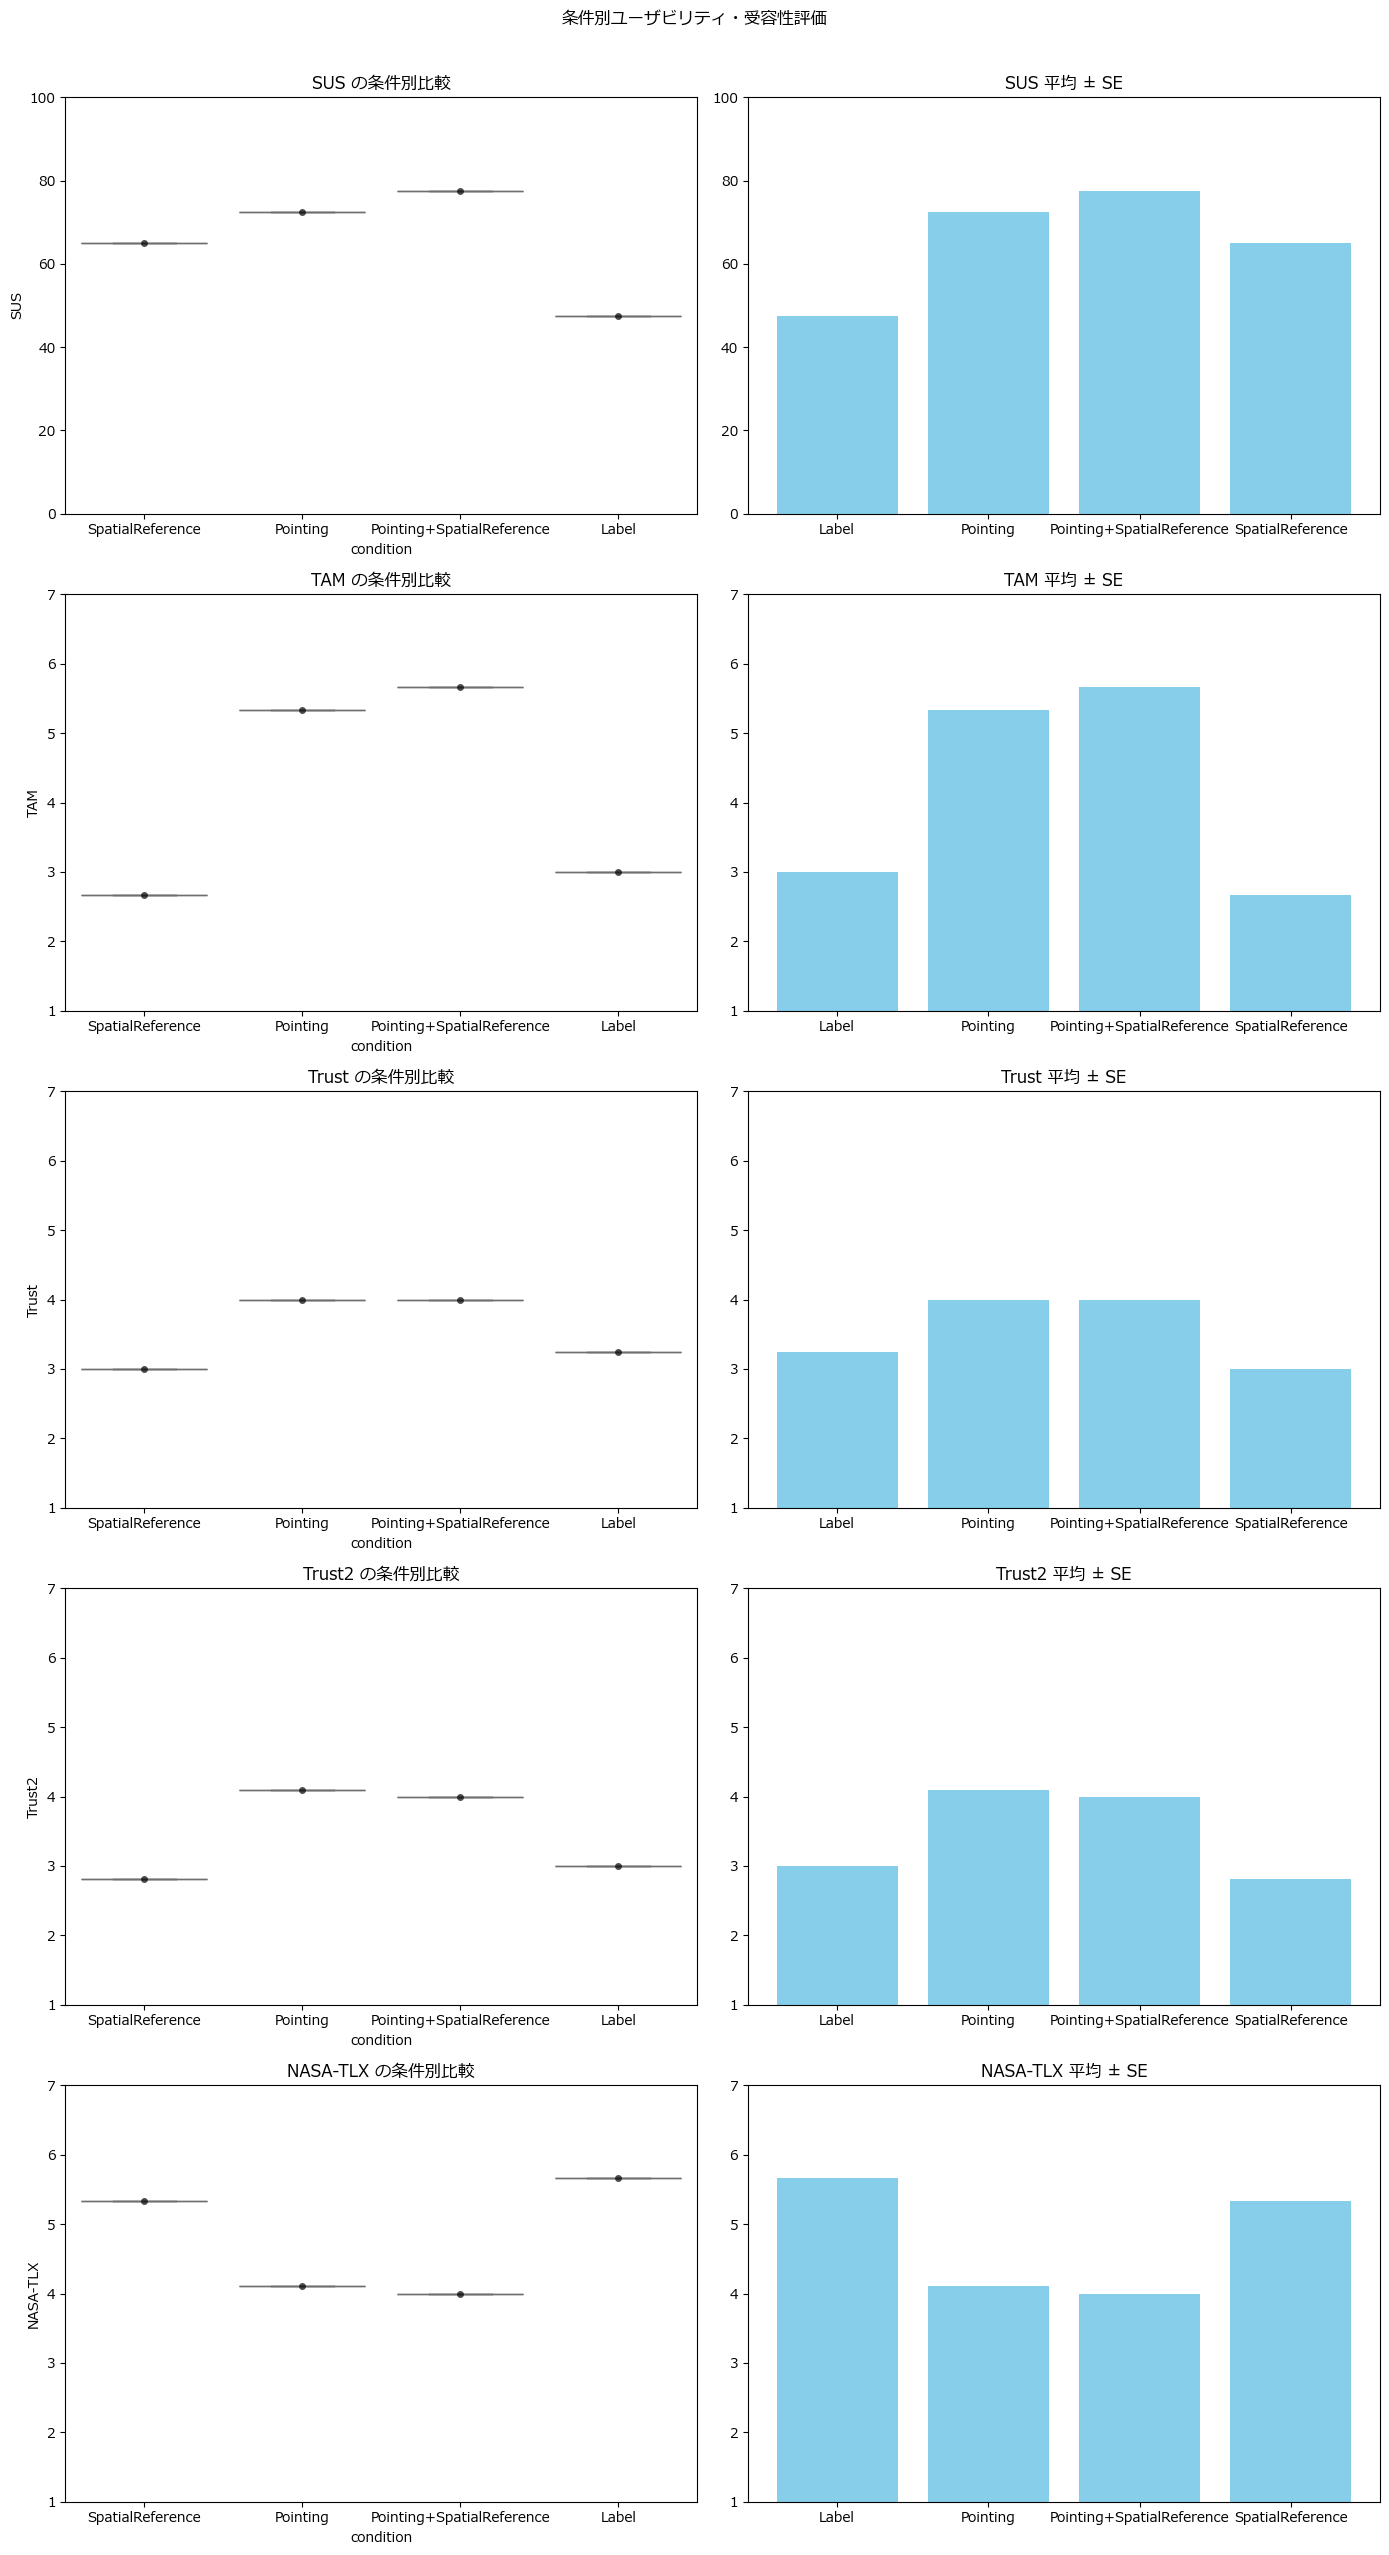

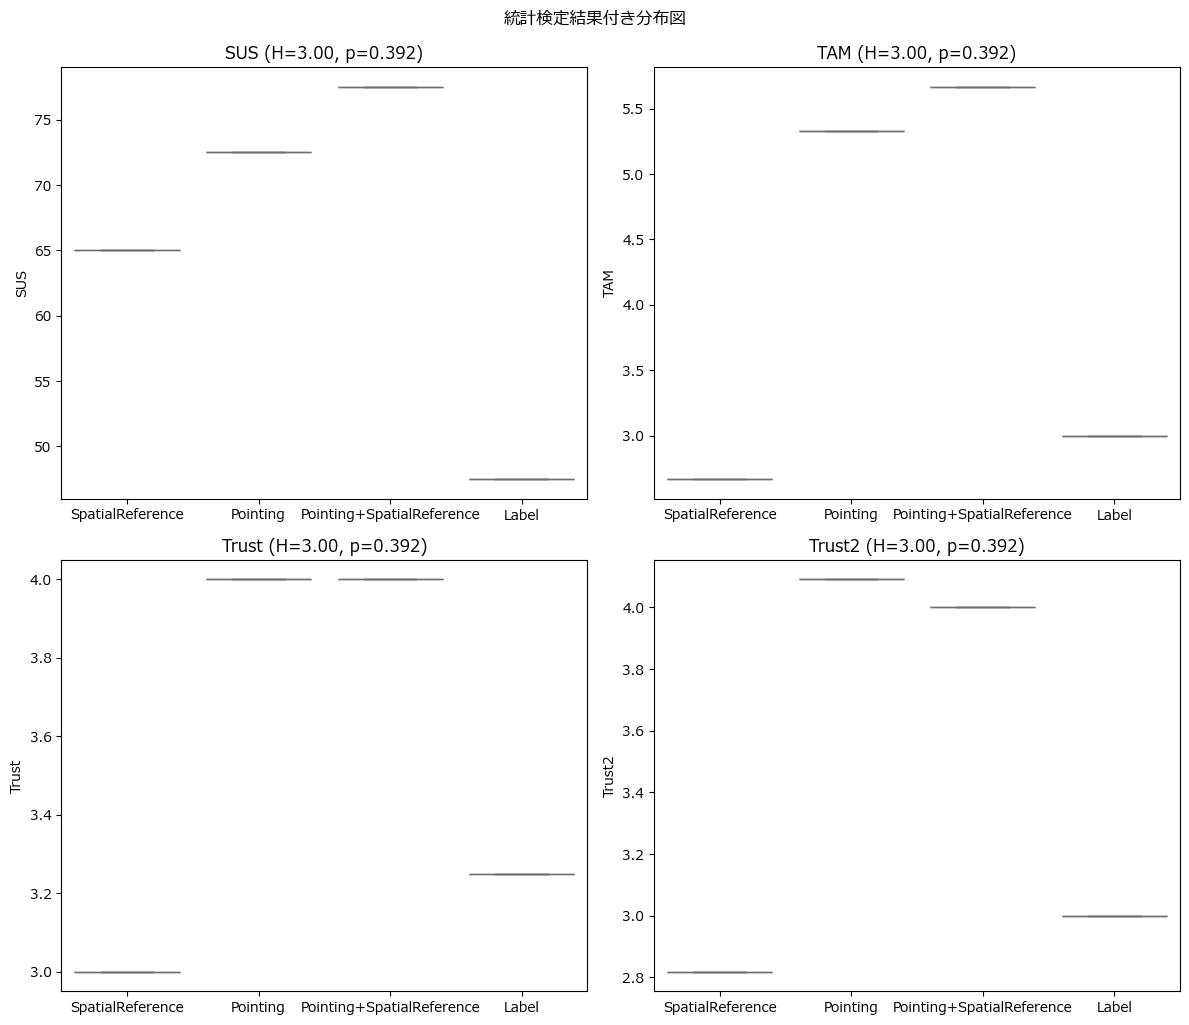

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'Meiryo'

# --- 定数定義 ---
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'trust':   list(range(14, 18)),  # Trust 14–17
    'trust2':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 38)),  # NASA-TLX 29–37
}
PARTICIPANT_COL = 38
CONDITION_COL   = 39
INVALID_IDS     = ['0', 'TEST', 'P2', 'OLD_P1']
CONDITION_MAP = {
    1: "Pointing+SpatialReference",
    2: "Label",
    3: "Pointing",
    4: "SpatialReference"
}

# --- データ読み込み & 前処理 ---
def load_and_preprocess(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, encoding='utf-8')
    df['participant_id'] = df.iloc[:, PARTICIPANT_COL].astype(str)
    df['condition']      = df.iloc[:, CONDITION_COL].astype(int)
    df = df[~df['participant_id'].isin(INVALID_IDS)].reset_index(drop=True)
    for key, cols in CATEGORY_COLUMNS.items():
        df[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)
    return df

# --- スコア計算 ---
def calc_sus_score(raw: list[int]) -> float:
    adj = [(s - 1) if i % 2 == 0 else (5 - s) for i, s in enumerate(raw)]
    return sum(adj) * 2.5

def compute_mean(vals: list[int]) -> float:
    return np.mean(vals)

def reverse_scoring(df: pd.DataFrame) -> pd.DataFrame:
    df['trust2'] = df['trust2'].apply(lambda v: [6 - x if i in (8,9) else x for i, x in enumerate(v)])
    df['nasa']   = df['nasa'].apply(lambda v: [6 - x if i == 3 else x for i, x in enumerate(v)])
    return df

# --- 統計検定用 ---
def run_kruskal(label: str, df: pd.DataFrame) -> tuple[float, float]:
    groups = [df[df['condition'] == c][label] for c in CONDITION_MAP.values()]
    return kruskal(*groups)

# --- メイン ---
def main():
    # データ読み込み・前処理
    df = load_and_preprocess('SurvayResult.csv')
    df = reverse_scoring(df)

    # スコア DataFrame 作成
    metrics = {
        'SUS':     ('sus',    calc_sus_score, 0, 100),
        'TAM':     ('tam',    compute_mean,   1,   7),
        'Trust':   ('trust',  compute_mean,   1,   7),
        'Trust2':  ('trust2', compute_mean,   1,   7),
        'NASA-TLX':('nasa',   compute_mean,   1,   7),
    }
    dfs = {}
    for name, (key, func, ymin, ymax) in metrics.items():
        dfs[name] = pd.DataFrame({
            'participant_id': df['participant_id'],
            'condition':      df['condition'],
            name:              df[key].apply(func)
        })

    # 条件ラベル適用
    for dfm in dfs.values():
        dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

    # 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
    fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
    for i, (name, dfm) in enumerate(dfs.items()):
        ymin, ymax = metrics[name][2], metrics[name][3]
        # 箱ひげ＋スウォーム
        ax = axes1[i, 0]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        sns.swarmplot(data=dfm, x='condition', y=name, color='black', alpha=0.7, ax=ax)
        ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
        # 平均±SEバー
        ax2 = axes1[i, 1]
        means = dfm.groupby('condition')[name].mean()
        sems  = dfm.groupby('condition')[name].sem()
        ax2.bar(means.index.astype(str), means, yerr=sems, capsize=5, color='skyblue')
        ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
    plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
    plt.savefig('survey_plots.png', dpi=300)

    # 2. 統計検定 & 結果表示
    stats = {}
    for name in ['SUS','TAM','Trust','Trust2']:
        stat, p = run_kruskal(name, dfs[name])
        stats[name] = (stat, p)
        print(f"{name}: H={stat:.3f}, p={p:.3f}")
        if p < 0.05:
            print(sp.posthoc_dunn(dfs[name], val_col=name, group_col='condition', p_adjust='bonferroni'))

    # 3. 統計結果付きボックスプロット
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, name in zip(axes2.flat, ['SUS','TAM','Trust','Trust2']):
        dfm = dfs[name]
        stat, p = stats[name]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        ax.set_title(f"{name} (H={stat:.2f}, p={p:.3f})")
        ax.set_xlabel(''); ax.set_ylabel(name)
    plt.tight_layout(); plt.suptitle('統計検定結果付き分布図', y=1.02)
    plt.savefig('stats_boxplots.png', dpi=300)
    plt.show()

if __name__ == '__main__':
    main()


In [106]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import scikit_posthocs as sp

# 条件名のマッピング
condition_labels = {
    1: "Prompting (WoZ)",
    2: "Label (WoZ)",
    3: "Pointing (WoZ)",
    4: "Prompting (System)"
}

# DataFrameリストと対応する列名・ラベル
score_dfs = [
    ("SUS", df_sus, "sus_score"),
    ("TAM", df_tam, "tam_score"),
    ("Trust", df_trust, "trust_score"),
    ("Trust2", df_trust2, "trust2_score")
]

# すべてのDataFrameで条件ラベルを適用
for _, df, _ in score_dfs:
    df["condition"] = df["condition"].replace(condition_labels)

# 有意差検定と事後検定
for label, df, score_col in score_dfs:
    print(f"\n🔎 {label} の有意差検定")

    # Kruskal-Wallis検定
    groups = [df[df["condition"] == cond][score_col] for cond in condition_labels.values()]
    stat, p = kruskal(*groups)
    print(f"Kruskal-Wallis 統計量 = {stat:.4f}, p値 = {p:.4f}")

    # 有意差があった場合のみ事後検定
    if p < 0.05:
        print("➡️ 有意差あり → Dunn’s test（Bonferroni補正）")
        posthoc = sp.posthoc_dunn(df, val_col=score_col, group_col="condition", p_adjust='bonferroni')
        print(posthoc)
    else:
        print("❎ 有意差なし → Dunn’s test はスキップ")



🔎 SUS の有意差検定
Kruskal-Wallis 統計量 = 1.6579, p値 = 0.6463
❎ 有意差なし → Dunn’s test はスキップ

🔎 TAM の有意差検定
Kruskal-Wallis 統計量 = 2.7911, p値 = 0.4250
❎ 有意差なし → Dunn’s test はスキップ

🔎 Trust の有意差検定
Kruskal-Wallis 統計量 = 0.7368, p値 = 0.8645
❎ 有意差なし → Dunn’s test はスキップ

🔎 Trust2 の有意差検定
Kruskal-Wallis 統計量 = 1.7278, p値 = 0.6308
❎ 有意差なし → Dunn’s test はスキップ


In [69]:
df_tam

,participant_id,condition,tam_score,condition_label
8,P1,Prompting (WoZ),7.000000,Prompting (WoZ)
9,P1,Prompting (System),7.000000,Prompting (System)
10,P1,Label (WoZ),4.333333,Label (WoZ)
11,P1,Pointing (WoZ),7.000000,Pointing (WoZ)


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'Meiryo'

# --- 定数定義 ---
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'trust':   list(range(14, 18)),  # Trust 14–17
    'trust2':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 38)),  # NASA-TLX 29–37
}
PARTICIPANT_COL = 38
CONDITION_COL   = 39
INVALID_IDS     = ['0', 'TEST', 'P2', 'OLD_P1']
CONDITION_MAP = {
    1: "Pointing+SpatialReference",
    2: "Label",
    3: "Pointing",
    4: "SpatialReference"
}

# --- データ読み込み & 前処理 ---
def load_and_preprocess(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, encoding='utf-8')
    df['participant_id'] = df.iloc[:, PARTICIPANT_COL].astype(str)
    df['condition']      = df.iloc[:, CONDITION_COL].astype(int)
    df = df[~df['participant_id'].isin(INVALID_IDS)].reset_index(drop=True)
    for key, cols in CATEGORY_COLUMNS.items():
        df[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)
    return df

# --- スコア計算 ---
def calc_sus_score(raw: list[int]) -> float:
    adj = [(s - 1) if i % 2 == 0 else (5 - s) for i, s in enumerate(raw)]
    return sum(adj) * 2.5

def compute_mean(vals: list[int]) -> float:
    return np.mean(vals)

def reverse_scoring(df: pd.DataFrame) -> pd.DataFrame:
    df['trust2'] = df['trust2'].apply(lambda v: [6 - x if i in (8,9) else x for i, x in enumerate(v)])
    df['nasa']   = df['nasa'].apply(lambda v: [6 - x if i == 3 else x for i, x in enumerate(v)])
    return df

# --- 統計検定用 ---
def run_kruskal(label: str, df: pd.DataFrame) -> tuple[float, float]:
    groups = [df[df['condition'] == c][label] for c in CONDITION_MAP.values()]
    return kruskal(*groups)

# --- メイン ---
def main():
    # データ読み込み・前処理
    df = load_and_preprocess('SurvayResult.csv')
    df = reverse_scoring(df)

    # スコア DataFrame 作成
    metrics = {
        'SUS':     ('sus',    calc_sus_score, 0, 100),
        'TAM':     ('tam',    compute_mean,   1,   7),
        'Trust':   ('trust',  compute_mean,   1,   7),
        'Trust2':  ('trust2', compute_mean,   1,   7),
        'NASA-TLX':('nasa',   compute_mean,   1,   7),
    }
    dfs = {}
    for name, (key, func, ymin, ymax) in metrics.items():
        dfs[name] = pd.DataFrame({
            'participant_id': df['participant_id'],
            'condition':      df['condition'],
            name:              df[key].apply(func)
        })

    # 条件ラベル適用
    for dfm in dfs.values():
        dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

    # 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
    fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
    for i, (name, dfm) in enumerate(dfs.items()):
        ymin, ymax = metrics[name][2], metrics[name][3]
        # 箱ひげ＋スウォーム
        ax = axes1[i, 0]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
        ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
        # 平均±SEバー
        ax2 = axes1[i, 1]
        means = dfm.groupby('condition')[name].mean()
        sems  = dfm.groupby('condition')[name].sem()
        ax2.bar(means.index, means, yerr=sems, capsize=5)
        ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
    plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
    plt.savefig('survey_plots.png', dpi=300)

    # 2. 統計検定 & 結果表示
    stats = {}
    for name in ['SUS','TAM','Trust','Trust2']:
        stat, p = run_kruskal(name, dfs[name])
        stats[name] = (stat, p)
        print(f"{name}: H={stat:.3f}, p={p:.3f}")
        if p < 0.05:
            print(sp.posthoc_dunn(dfs[name], val_col=name, group_col='condition', p_adjust='bonferroni'))

    # 3. 統計結果付きボックスプロット
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, name in zip(axes2.flat, ['SUS','TAM','Trust','Trust2']):
        dfm = dfs[name]
        stat, p = stats[name]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        ax.set_title(f"{name} (H={stat:.2f}, p={p:.3f})")
        ax.set_xlabel(''); ax.set_ylabel(name)
    plt.tight_layout(); plt.suptitle('統計検定結果付き分布図', y=1.02)
    plt.savefig('stats_boxplots.png', dpi=300)
    plt.show()



C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Te

SUS: H=3.000, p=0.392
TAM: H=3.000, p=0.392
Trust: H=3.000, p=0.392
Trust2: H=3.000, p=0.392


C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local\Temp\ipykernel_29852\1523712647.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
C:\Users\Tenma\AppData\Local

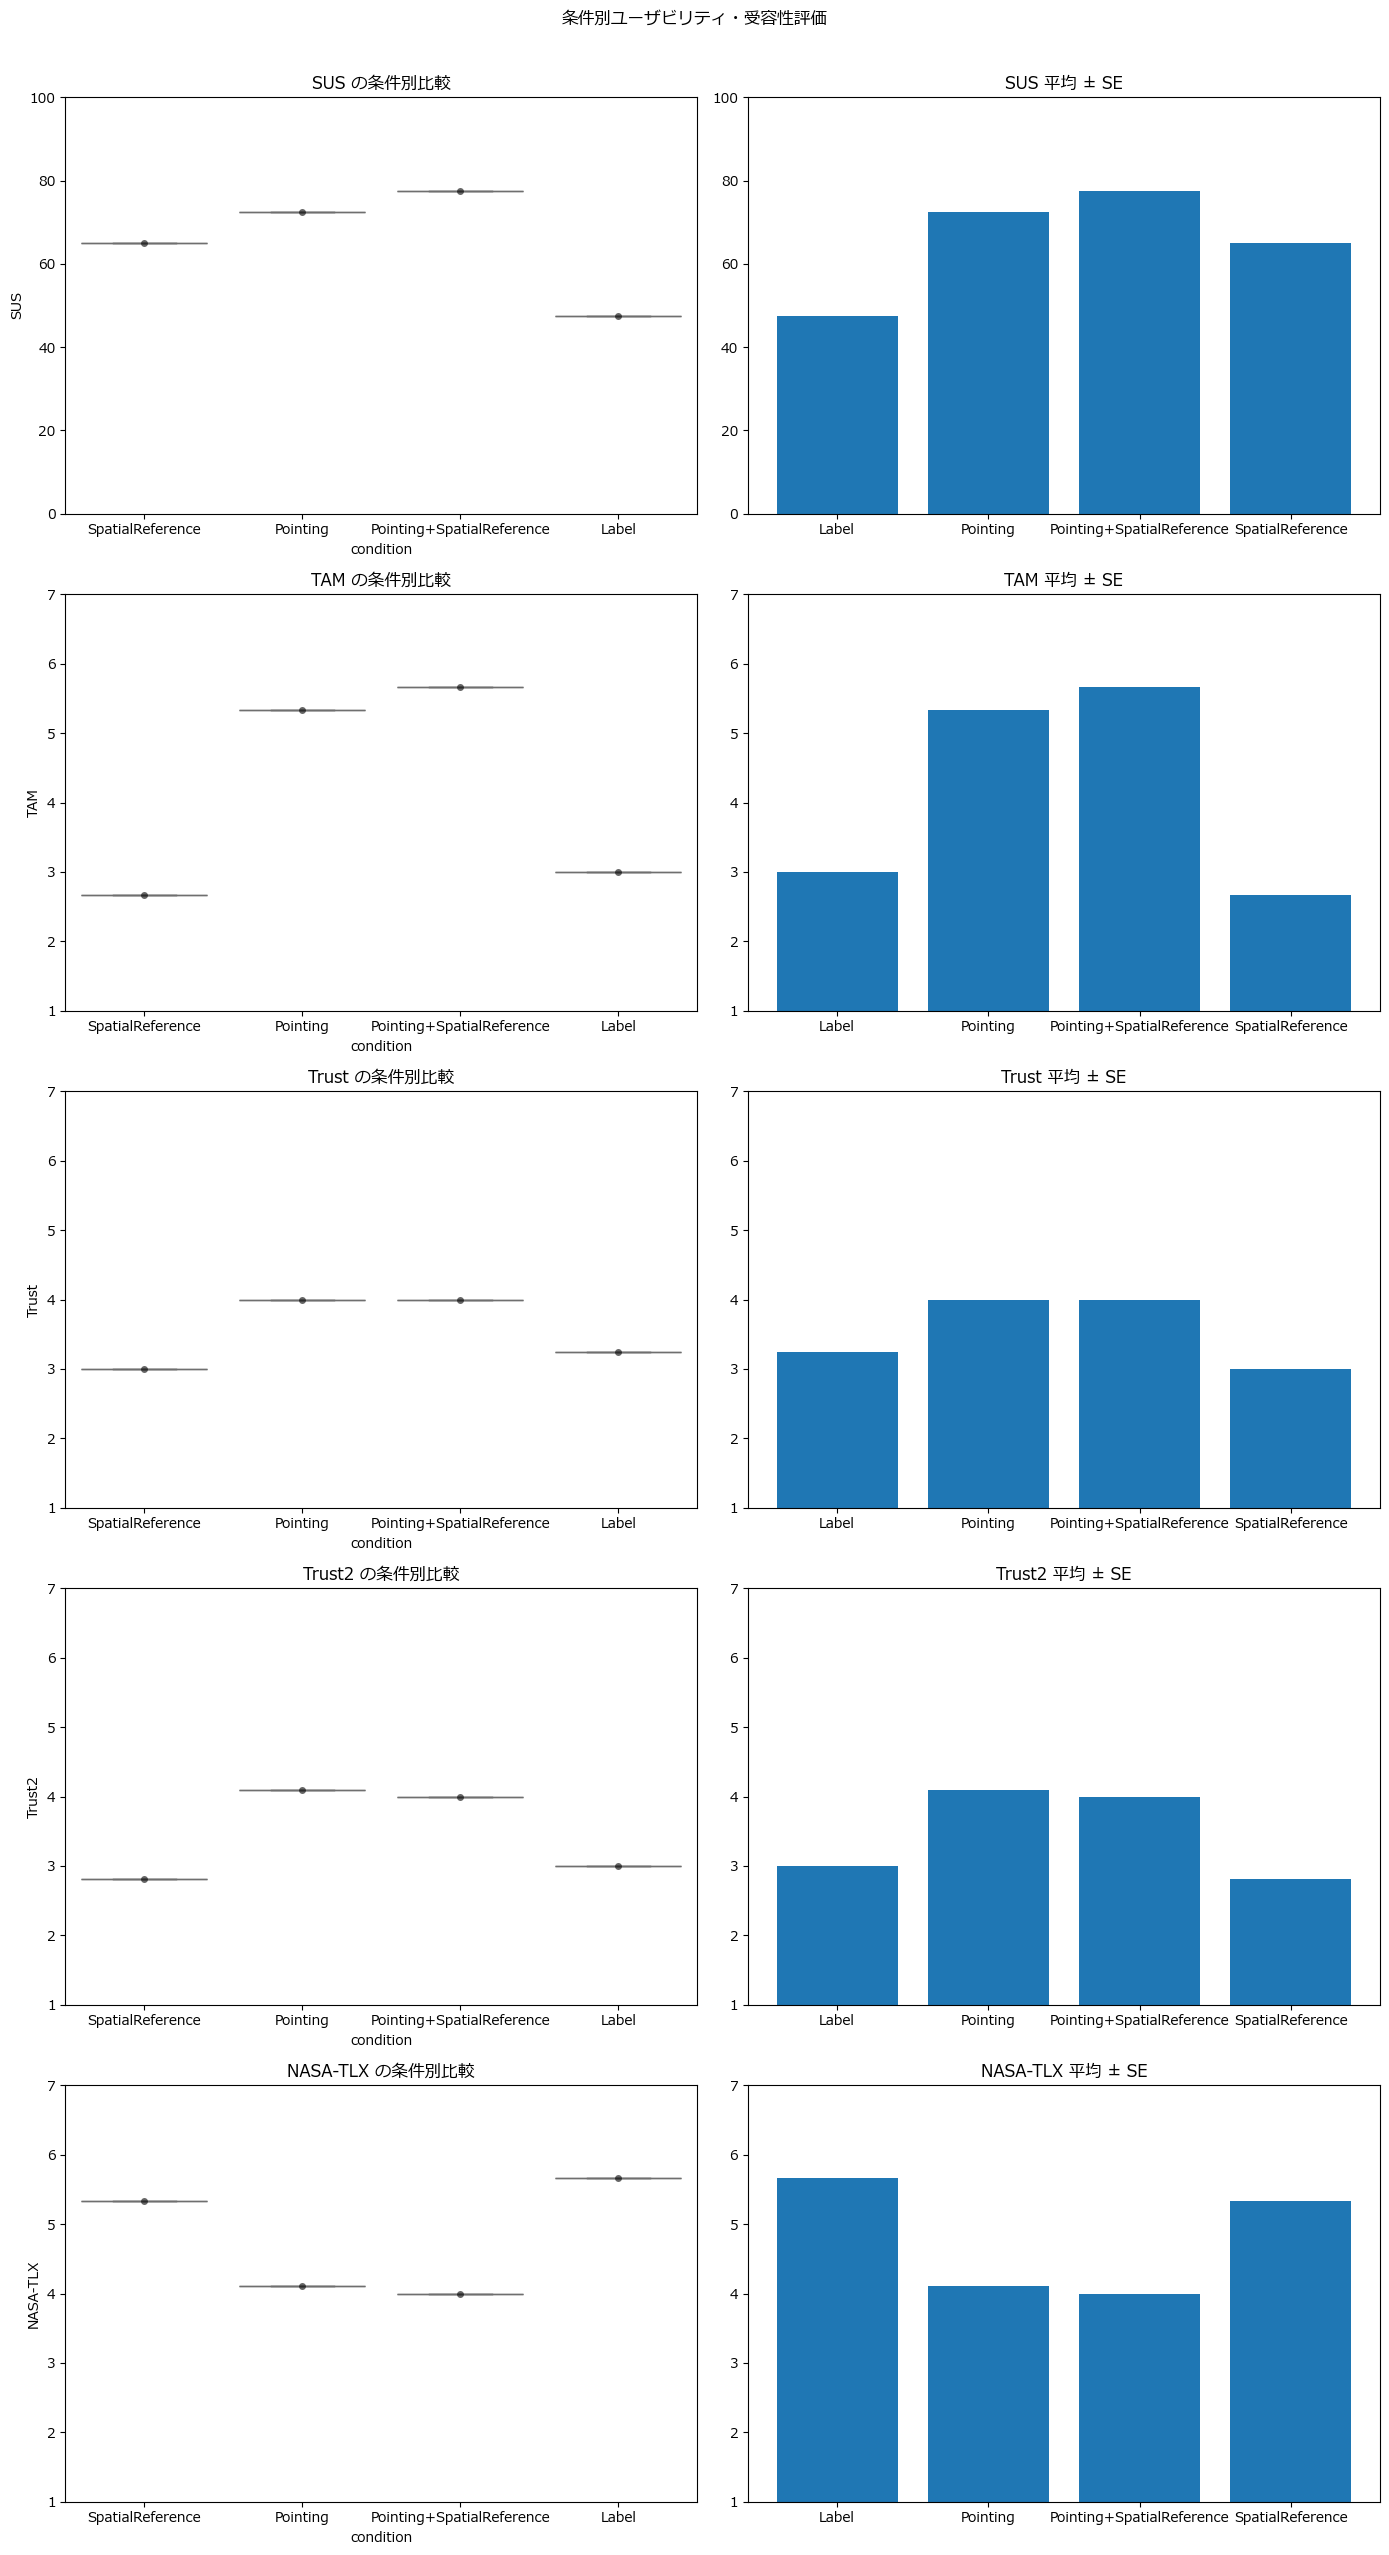

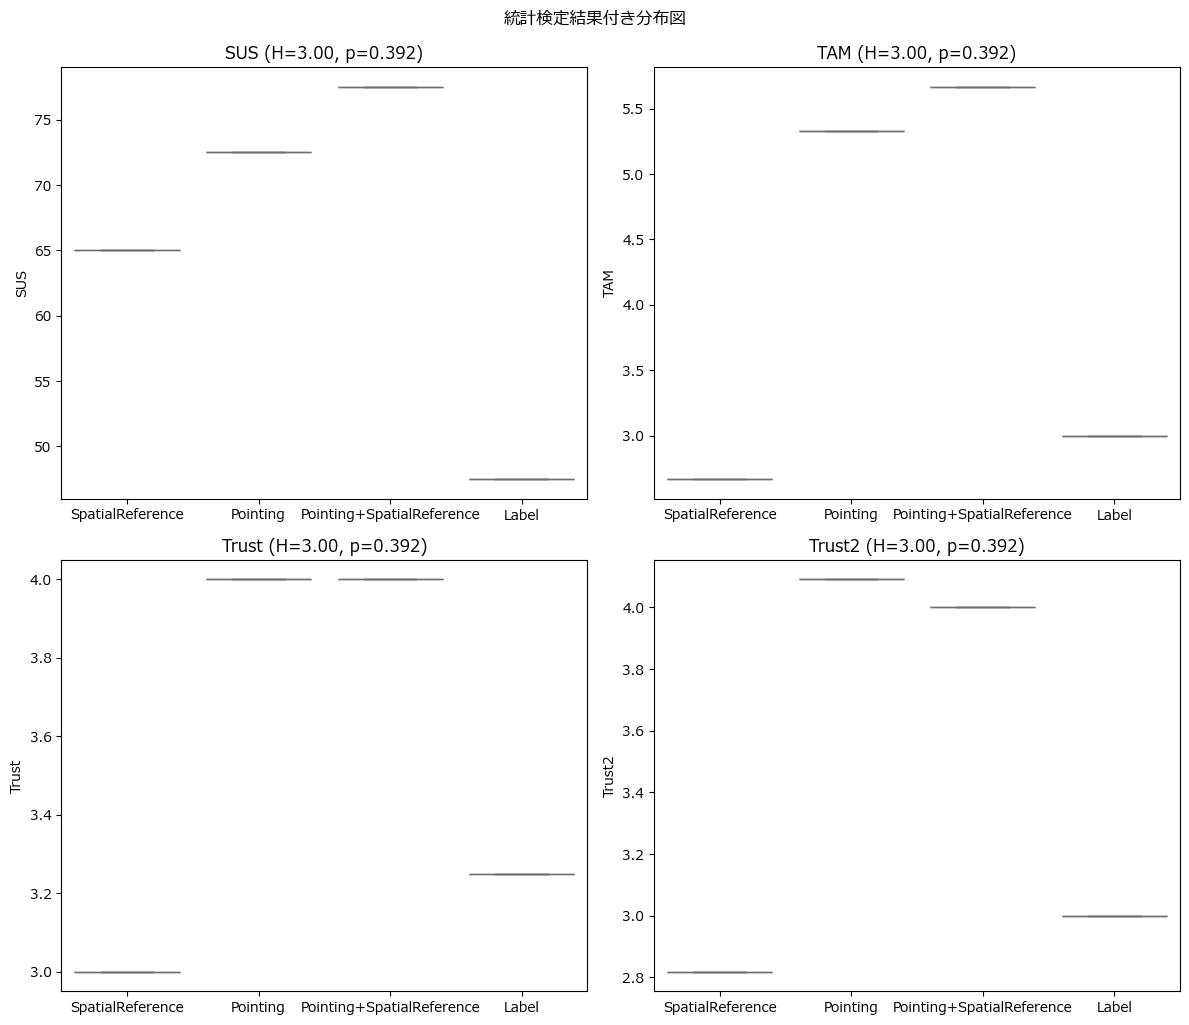

In [17]:
main()


!pip install scikit-posthocs